# 03 · Analyse the class map & score it against the truth
### DINO-4DSTEM tutorials

We have a trained model (notebook 02). Now we look at what it found and, because
this is a *synthetic* sample with known labels, **measure how good it is**.

**This notebook:** run the model → a class map → score it (accuracy, IoU, ARI,
NMI) → *what did it get wrong?* → the confusion & cosine matrices → the specific
domains → an interactive click inspector.

## The metrics, briefly

The model is **unsupervised**, so its cluster numbers are arbitrary — cluster
"2" isn't necessarily ground-truth class "2". Before scoring we **match** them:

- **Hungarian assignment.** Build the confusion matrix $C_{ij}$ = #pixels that
  are GT class $i$ *and* predicted class $j$, then find the one-to-one matching
  of predicted→true classes that **maximises the total overlap**
  ($\arg\max_\pi \sum_i C_{i,\pi(i)}$, solved with `linear_sum_assignment`).

Then we report:

- **Accuracy** — fraction of pixels correct *after* matching.
- **IoU** (intersection-over-union / Jaccard) per class:
  $\mathrm{IoU} = \dfrac{|A\cap B|}{|A\cup B|}$, and **Dice** $= \dfrac{2|A\cap B|}{|A|+|B|}$.
- **ARI** (adjusted Rand index) — agreement over all *pairs* of pixels,
  **corrected for chance** (0 = random, 1 = perfect). Needs no label matching.
- **NMI** (normalised mutual information) — how much knowing the prediction tells
  you about the truth, in $[0,1]$.

They answer slightly different questions, so we report all four.

In [1]:
import os, numpy as np
import ws2_utils as wu
wu.add_src_to_path(); wu.preimport()          # import analysis modules before inline
%matplotlib inline
import matplotlib.pyplot as plt

ex = wu.find_ws2_example(); ck = wu.find_ws2_checkpoint()
cube = np.load(os.path.join(ex, 'phantom.cube.npy'), mmap_mode='r')
gt   = np.load(os.path.join(ex, 'phantom.classmap_main.npy'))
Ny, Nx = gt.shape

## 1 · Run the model → a class map

`run_dino_inference` loads the checkpoint, pushes every pattern through it, and
reshapes the assignments to a 2-D map. It reuses the crop / beam-mask / `vmax`
the model was trained with. (Loads the pre-computed result; pass
`use_cache=False` to recompute from the checkpoint, ~45 s on CPU.)

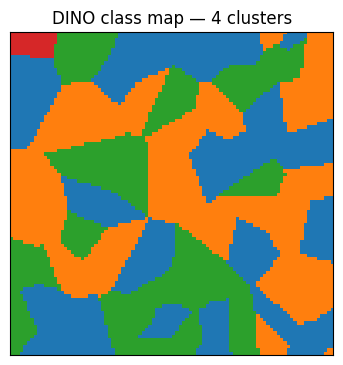

In [2]:
r = wu.run_dino_inference(os.path.join(ex, 'phantom.cube.npy'), ck,
                          scan_shape=(Ny, Nx), use_cache=True)
class_map = r['class_map']

fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.imshow(class_map, cmap=wu.class_palette(r['K']), interpolation='nearest')
ax.set_title(f'DINO class map — {r["K"]} clusters')
ax.set_xticks([]); ax.set_yticks([]); plt.show()

## 2 · Ground truth vs result

Green in the agreement panel = a correctly-labelled pixel.

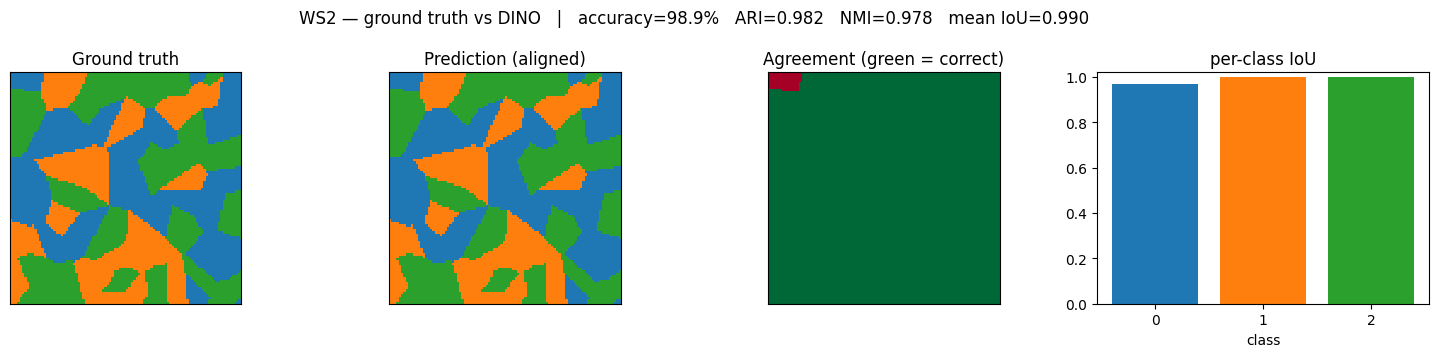

In [3]:
score = wu.align_and_score(gt, class_map)
wu.plot_gt_vs_pred(gt, score, title='WS2 — ground truth vs DINO'); plt.show()

## 3 · What did it get wrong?

DINO found **more clusters than the 3 ground-truth classes**. Below: *all* the
clusters, exactly where the prediction disagrees with the truth, and the
diffraction of the extra (unmatched) cluster — so we can judge whether a
"mistake" is really a mistake.

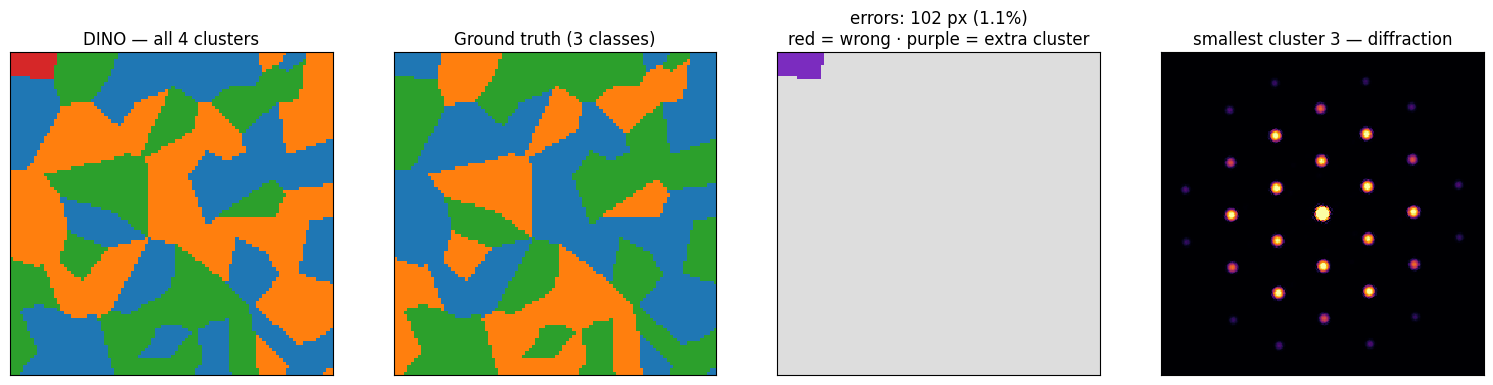

In [4]:
fig, _ = wu.plot_errors(cube, class_map, gt); plt.show()

Notice the disagreements are **not scattered noise** — they are one small
grain that DINO split into its own cluster, and that cluster's diffraction is a
clean single-crystal pattern. So the "error" is an **over-split of a real
domain** (the classic "K a little too high" behaviour), not a misclassification.
Merging that cluster would take it to 100%.

## 4 · Confusion matrix

Rows = true class, columns = predicted (aligned); the last column collects any
unmatched extra cluster. A near-diagonal matrix means clean separation.

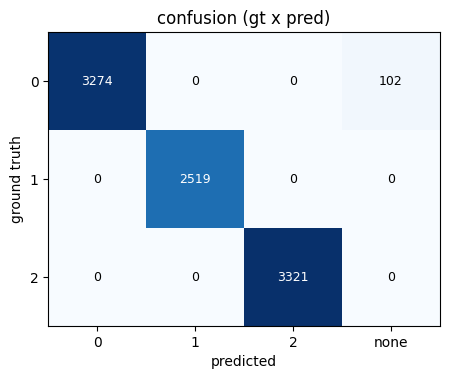

In [5]:
conf = score['confusion']; K = score['K_gt']
fig, ax = plt.subplots(figsize=(4.6, 4))
ax.imshow(conf, cmap='Blues')
ax.set_xticks(range(conf.shape[1])); ax.set_xticklabels([str(i) for i in range(K)] + ['none'])
ax.set_yticks(range(K)); ax.set_xlabel('predicted'); ax.set_ylabel('ground truth')
for i in range(K):
    for j in range(conf.shape[1]):
        ax.text(j, i, int(conf[i, j]), ha='center', va='center', fontsize=9,
                color='white' if conf[i, j] > conf.max()/2 else 'black')
ax.set_title('confusion (gt x pred)'); plt.tight_layout(); plt.show()

## 5 · Cosine-similarity matrix

How distinct are the classes in the model's **embedding space**? Each entry is
the cosine similarity between two classes' mean embeddings. Small off-diagonal
values = well-separated classes.

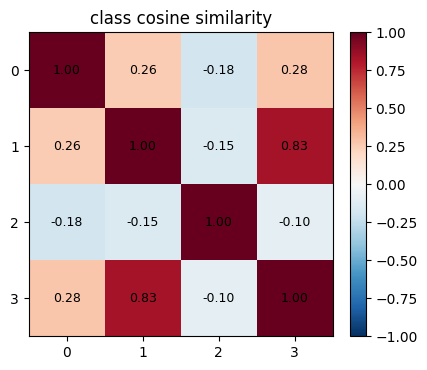

In [6]:
cos = wu.cosine_matrix(r['embeds'], r['assigns'], r['K'])
fig, ax = plt.subplots(figsize=(4.4, 3.8))
im = ax.imshow(cos, cmap='RdBu_r', vmin=-1, vmax=1)
for i in range(cos.shape[0]):
    for j in range(cos.shape[0]):
        ax.text(j, i, f'{cos[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_xticks(range(cos.shape[0])); ax.set_yticks(range(cos.shape[0]))
ax.set_title('class cosine similarity'); plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 6 · The specific domains

Pick the largest grain of each class, outline it on the map, and show its own
diffraction (a single grain → sharp Bragg spots, not the ring-averaged mean).

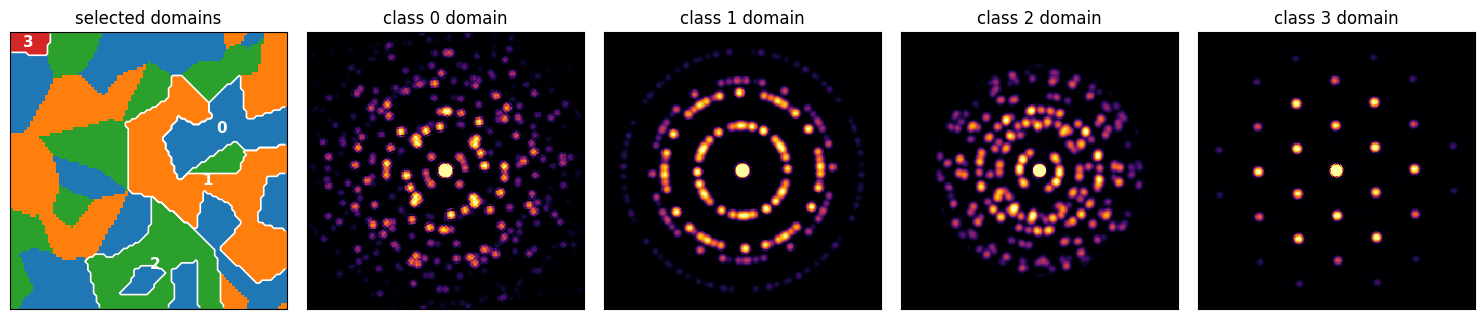

In [7]:
wu.show_domains(cube, class_map, per_class=1); plt.show()

## 7 · Inspect it yourself — click the map

Run the two lines below in Jupyter to get a **live** inspector like the app:

```python
%matplotlib widget
wu.interactive_click(cube, class_map=class_map)
```

**Left-click** a point → that single diffraction pattern. **Right-click** → the
average over the whole grain it belongs to. (A static snapshot runs below so the
notebook executes end-to-end.)

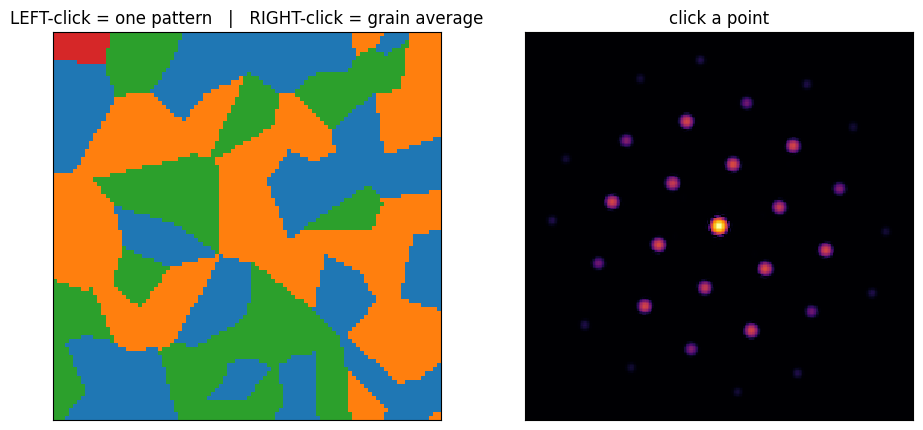

In [8]:
wu.interactive_click(cube, class_map=class_map); plt.show()

### Done

DINO recovered the 3 WS2 orientations at **~99% / ARI 0.98**, its classes are
well-separated in embedding space, and its only "error" was over-splitting one
grain. It never saw a label.

**Next → `04_NMF_kmeans.ipynb`**: how a classical NMF + KMeans baseline compares.